# 🤗 x 🦾: Training SmolVLA with LeRobot Notebook

Welcome to the **LeRobot SmolVLA training notebook**! This notebook provides a ready-to-run setup for training imitation learning policies using the [🤗 LeRobot](https://github.com/huggingface/lerobot) library.

In this example, we train an `SmolVLA` policy using a dataset hosted on the [Hugging Face Hub](https://huggingface.co/), and optionally track training metrics with [Weights & Biases (wandb)](https://wandb.ai/).

## ⚙️ Requirements
- A Hugging Face dataset repo ID containing your training data (`--dataset.repo_id=YOUR_USERNAME/YOUR_DATASET`)
- Optional: A [wandb](https://wandb.ai/) account if you want to enable training visualization
- Recommended: GPU runtime (e.g., NVIDIA A100) for faster training

## ⏱️ Expected Training Time
Training with the `SmolVLA` policy for 20,000 steps typically takes **about 5 hours on an NVIDIA A100** GPU. On less powerful GPUs or CPUs, training may take significantly longer!

## Example Output
Model checkpoints, logs, and training plots will be saved to the specified `--output_dir`. If `wandb` is enabled, progress will also be visualized in your wandb project dashboard.


## Install conda
This cell uses `condacolab` to bootstrap a full Conda environment inside Google Colab.


In [1]:
!pip install -q condacolab
import condacolab
condacolab.install()

✨🍰✨ Everything looks OK!


## Install LeRobot
This cell clones the `lerobot` repository from Hugging Face, installs FFmpeg (version 7.1.1), and installs the package in editable mode.


In [2]:
!conda install python=3.12 -y
!python --version

Channels:
 - conda-forge
Platform: linux-64
Solving environment: | / - done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - python=3.12


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    brotli-python-1.2.0        |  py312hdb49522_1         360 KB  conda-forge
    c-ares-1.34.6              |       hb03c661_0         203 KB  conda-forge
    ca-certificates-2026.2.25  |       hbd8a1cb_0         144 KB  conda-forge
    certifi-2026.2.25          |     pyhd8ed1ab_0         148 KB  conda-forge
    cffi-2.0.0                 |  py312h460c074_1         289 KB  conda-forge
    conda-26.1.1               |  py312h7900ff3_0         1.2 MB  conda-forge
    conda-libmamba-solver-25.11.0|     pyhd8ed1ab_1          56 KB  conda-forge
    cpp-expected-1.3.1         |       h171cf75_0          24 KB  conda-forge
    fmt-12.1.0                 |       hff5e90

In [3]:
!rm -rf lerobot
!git clone https://github.com/mdas64/lerobot.git
!conda install ffmpeg=7.1.1 -c conda-forge
!cd lerobot && pip install -e .

Cloning into 'lerobot'...
remote: Enumerating objects: 16570, done.
remote: Counting objects: 100% (169/169), done.
remote: Compressing objects: 100% (153/153), done.
remote: Total 16570 (delta 57), reused 16 (delta 16), pack-reused 16401 (from 3)
Receiving objects: 100% (16570/16570), 113.08 MiB | 19.75 MiB/s, done.
Resolving deltas: 100% (8698/8698), done.
Filtering content: 100% (45/45), 69.03 MiB | 4.71 MiB/s, done.
Channels:
 - conda-forge
Platform: linux-64
Solving environment: | / - \ done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - ffmpeg=7.1.1


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    alsa-lib-1.2.15.3          |       hb03c661_0         571 KB  conda-forge
    aom-3.9.1                  |       hac33072_0         2.6 MB  conda-forge
    attr-2.5.2                 |       hb03c661_1          31 KB  conda-forge
    cairo

## Weights & Biases login
This cell logs you into Weights & Biases (wandb) to enable experiment tracking and logging.

In [4]:
!wandb login

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: milpdio (milpdio-georgia-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Install SmolVLA dependencies

In [5]:
!cd lerobot && pip install -e ".[smolvla]"

Obtaining file:///content/lerobot
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 163.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 136.3 MB/s eta 0:00:00
  Building editable for lerobot (pyproject.toml) ... done
  Created wheel for lerobot: filename=lerobot-0.5.1-0.editable-py3-none-any.whl size=12938 sha256=35fb74d7fd20f43a78b965378e180f134b04c0707eb77aec12f0b356aafc9b10
  Stored in directory: /tmp/pip-ephem-wheel-cache-base9xdh/wheels/09/b4/fe/75732b1d640db96ba1f856f2b7328b232a03b696a39cb59686
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13781 sha256=128074f5156eda0ef6c7085a87d80a257c78dcb01fac989bdbd04801fb0d9722
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4c

In [7]:
import sys, os, importlib, shutil

# Remove cached module
if 'egl_probe' in sys.modules:
    del sys.modules['egl_probe']

# Find ALL egl_probe locations and nuke them
import subprocess
result = subprocess.run(
    ["find", "/", "-type", "d", "-name", "egl_probe", "-not", "-path", "*/proc/*"],
    capture_output=True, text=True, timeout=30
)
print("Found egl_probe directories:")
print(result.stdout)

# Also check for single-file module
result2 = subprocess.run(
    ["find", "/", "-name", "egl_probe.py", "-not", "-path", "*/proc/*"],
    capture_output=True, text=True, timeout=30
)
print("Found egl_probe.py files:")
print(result2.stdout)

# Also check for .so files
result3 = subprocess.run(
    ["find", "/", "-name", "egl_probe*.so", "-not", "-path", "*/proc/*"],
    capture_output=True, text=True, timeout=30
)
print("Found egl_probe .so files:")
print(result3.stdout)

Found egl_probe directories:

Found egl_probe.py files:

Found egl_probe .so files:



In [8]:
import sys, os, shutil, importlib

# Remove cached module
if 'egl_probe' in sys.modules:
    del sys.modules['egl_probe']

# Remove every egl_probe directory and file found
import subprocess

# Find and delete all egl_probe directories
result = subprocess.run(
    ["find", "/", "-type", "d", "-name", "egl_probe", "-not", "-path", "*/proc/*"],
    capture_output=True, text=True, timeout=30
)
for d in result.stdout.strip().split('\n'):
    if d:
        print(f"Removing directory: {d}")
        shutil.rmtree(d, ignore_errors=True)

# Find and delete all egl_probe.py files
result2 = subprocess.run(
    ["find", "/", "-name", "egl_probe.py", "-not", "-path", "*/proc/*"],
    capture_output=True, text=True, timeout=30
)
for f in result2.stdout.strip().split('\n'):
    if f:
        print(f"Removing file: {f}")
        os.remove(f)

# Find and delete all egl_probe .so files
result3 = subprocess.run(
    ["find", "/", "-name", "egl_probe*.so", "-not", "-path", "*/proc/*"],
    capture_output=True, text=True, timeout=30
)
for f in result3.stdout.strip().split('\n'):
    if f:
        print(f"Removing .so file: {f}")
        os.remove(f)

# Now create our stub fresh
site_packages = "/usr/local/lib/python3.12/dist-packages"
egl_probe_dir = os.path.join(site_packages, "egl_probe")
os.makedirs(egl_probe_dir, exist_ok=True)

init_code = '''\
import os

def probe_devices():
    """Return available EGL render devices."""
    devices = []
    dri_path = "/dev/dri"
    if os.path.exists(dri_path):
        for f in sorted(os.listdir(dri_path)):
            if f.startswith("renderD"):
                devices.append(os.path.join(dri_path, f))
    if not devices:
        devices = ["/dev/dri/renderD128"]
    return devices

def get_device_count():
    return len(probe_devices())
'''

with open(os.path.join(egl_probe_dir, "__init__.py"), "w") as f:
    f.write(init_code)

print(f"\n✅ Stub written to: {egl_probe_dir}/__init__.py")
print(f"Contents exist: {os.path.exists(os.path.join(egl_probe_dir, '__init__.py'))}")

# Verify the file content
with open(os.path.join(egl_probe_dir, "__init__.py")) as f:
    print(f"\nFile contents:\n{f.read()}")

# Clear everything and reimport
importlib.invalidate_caches()
if 'egl_probe' in sys.modules:
    del sys.modules['egl_probe']

import egl_probe
print(f"\n✅ Imported from: {egl_probe.__file__}")
print(f"✅ probe_devices = {egl_probe.probe_devices()}")


✅ Stub written to: /usr/local/lib/python3.12/dist-packages/egl_probe/__init__.py
Contents exist: True

File contents:
import os

def probe_devices():
    """Return available EGL render devices."""
    devices = []
    dri_path = "/dev/dri"
    if os.path.exists(dri_path):
        for f in sorted(os.listdir(dri_path)):
            if f.startswith("renderD"):
                devices.append(os.path.join(dri_path, f))
    if not devices:
        devices = ["/dev/dri/renderD128"]
    return devices

def get_device_count():
    return len(probe_devices())


✅ Imported from: /usr/local/lib/python3.12/dist-packages/egl_probe/__init__.py
✅ probe_devices = ['/dev/dri/renderD128']


In [9]:
%%writefile /tmp/test_egl.py
import egl_probe
print(f"File: {egl_probe.__file__}")
print(f"Devices: {egl_probe.probe_devices()}")
print("✅ Works!")

Writing /tmp/test_egl.py


In [10]:
!python /tmp/test_egl.py

Traceback (most recent call last):
  File "/tmp/test_egl.py", line 1, in <module>
    import egl_probe
ModuleNotFoundError: No module named 'egl_probe'


In [11]:
%%writefile /tmp/check_python.py
import sys
print(f"Python binary: {sys.executable}")
print(f"Python version: {sys.version}")
print(f"sys.path:")
for p in sys.path:
    print(f"  {p}")

Writing /tmp/check_python.py


In [12]:
# Check what the shell python sees
!python /tmp/check_python.py

Python binary: /usr/local/bin/python
Python version: 3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 16:50:00) [GCC 14.3.0]
sys.path:
  /tmp
  /env/python
  /usr/local/lib/python312.zip
  /usr/local/lib/python3.12
  /usr/local/lib/python3.12/lib-dynload
  /usr/local/lib/python3.12/site-packages
  /content/lerobot/src
  /usr/local/lib/python3.12/site-packages/rerun_sdk


In [13]:
# Check what the Jupyter kernel sees
import sys
print(f"Kernel Python: {sys.executable}")
print(f"Kernel version: {sys.version}")

Kernel Python: /usr/bin/python3.real
Kernel version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [14]:
import subprocess, os

# Find every Python's site-packages
result = subprocess.run(
    ["find", "/", "-type", "d", "-name", "dist-packages", "-path", "*/python3.12/*",
     "-not", "-path", "*/proc/*"],
    capture_output=True, text=True, timeout=30
)
print("All dist-packages locations:")
print(result.stdout)

result2 = subprocess.run(
    ["find", "/", "-type", "d", "-name", "site-packages", "-path", "*/python3.12/*",
     "-not", "-path", "*/proc/*"],
    capture_output=True, text=True, timeout=30
)
print("All site-packages locations:")
print(result2.stdout)

All dist-packages locations:
/usr/local/lib/python3.12/dist-packages

All site-packages locations:
/usr/local/lib/python3.12/site-packages
/usr/local/pkgs/zstandard-0.25.0-py312h5253ce2_1/lib/python3.12/site-packages
/usr/local/pkgs/ruamel.yaml-0.18.17-py312h5253ce2_2/lib/python3.12/site-packages
/usr/local/pkgs/frozendict-2.4.7-py312h4c3975b_0/lib/python3.12/site-packages
/usr/local/pkgs/conda-26.1.1-py312h7900ff3_0/lib/python3.12/site-packages
/usr/local/pkgs/python-3.12.13-hd63d673_0_cpython/lib/python3.12/site-packages
/usr/local/pkgs/msgpack-python-1.1.2-py312hd9148b4_1/lib/python3.12/site-packages
/usr/local/pkgs/cffi-2.0.0-py312h460c074_1/lib/python3.12/site-packages
/usr/local/pkgs/menuinst-2.4.2-py312h7900ff3_0/lib/python3.12/site-packages
/usr/local/pkgs/brotli-python-1.2.0-py312hdb49522_1/lib/python3.12/site-packages
/usr/local/pkgs/pycosat-0.6.6-py312h4c3975b_3/lib/python3.12/site-packages
/usr/local/pkgs/libmambapy-2.5.0-py312h04b9399_0/lib/python3.12/site-packages
/usr/lo

In [15]:
import os

stub_code = '''\
import os

def probe_devices():
    """Return available EGL render devices."""
    devices = []
    dri_path = "/dev/dri"
    if os.path.exists(dri_path):
        for f in sorted(os.listdir(dri_path)):
            if f.startswith("renderD"):
                devices.append(os.path.join(dri_path, f))
    if not devices:
        devices = ["/dev/dri/renderD128"]
    return devices

def get_device_count():
    return len(probe_devices())
'''

# Write to every possible location
locations = [
    "/usr/local/lib/python3.12/dist-packages",
    "/usr/local/lib/python3.12/site-packages",
    "/usr/lib/python3/dist-packages",
    "/usr/lib/python3.12/dist-packages",
    "/usr/lib/python3.12/site-packages",
]

# Also add anything found by the search above
import subprocess
for cmd_args in [
    ["find", "/", "-type", "d", "-name", "dist-packages", "-path", "*python3*", "-not", "-path", "*/proc/*"],
    ["find", "/", "-type", "d", "-name", "site-packages", "-path", "*python3*", "-not", "-path", "*/proc/*"],
]:
    result = subprocess.run(cmd_args, capture_output=True, text=True, timeout=30)
    for line in result.stdout.strip().split('\n'):
        if line and line not in locations:
            locations.append(line)

for loc in locations:
    egl_dir = os.path.join(loc, "egl_probe")
    try:
        os.makedirs(egl_dir, exist_ok=True)
        with open(os.path.join(egl_dir, "__init__.py"), "w") as f:
            f.write(stub_code)
        print(f"✅ Written to: {egl_dir}")
    except Exception as e:
        print(f"❌ Failed for {egl_dir}: {e}")

✅ Written to: /usr/local/lib/python3.12/dist-packages/egl_probe
✅ Written to: /usr/local/lib/python3.12/site-packages/egl_probe
✅ Written to: /usr/lib/python3/dist-packages/egl_probe
✅ Written to: /usr/lib/python3.12/dist-packages/egl_probe
✅ Written to: /usr/lib/python3.12/site-packages/egl_probe
✅ Written to: /usr/local/lib/python3.10/dist-packages/egl_probe
✅ Written to: /usr/local/lib/python3.11/site-packages/egl_probe
✅ Written to: /usr/local/pkgs/zstandard-0.25.0-py312h5253ce2_1/lib/python3.12/site-packages/egl_probe
✅ Written to: /usr/local/pkgs/ruamel.yaml-0.18.10-py311h9ecbd09_0/lib/python3.11/site-packages/egl_probe
✅ Written to: /usr/local/pkgs/ruamel.yaml-0.18.17-py312h5253ce2_2/lib/python3.12/site-packages/egl_probe
✅ Written to: /usr/local/pkgs/frozendict-2.4.7-py312h4c3975b_0/lib/python3.12/site-packages/egl_probe
✅ Written to: /usr/local/pkgs/ruamel.yaml.clib-0.2.8-py311h9ecbd09_1/lib/python3.11/site-packages/egl_probe
✅ Written to: /usr/local/pkgs/python-3.11.11-h9e4cc

In [16]:
%%writefile /tmp/test_egl.py
import egl_probe
print("File:", egl_probe.__file__)
print("Devices:", egl_probe.probe_devices())
print("OK")

Overwriting /tmp/test_egl.py


In [17]:
# Test from shell python
!python /tmp/test_egl.py

# Also test with the full path
!which python
!/usr/bin/python3 /tmp/test_egl.py 2>/dev/null || echo "not at /usr/bin/python3"
!/usr/local/bin/python3 /tmp/test_egl.py 2>/dev/null || echo "not at /usr/local/bin/python3"
!/usr/local/bin/python /tmp/test_egl.py 2>/dev/null || echo "not at /usr/local/bin/python"

File: /usr/local/lib/python3.12/site-packages/egl_probe/__init__.py
Devices: ['/dev/dri/renderD128']
OK
/usr/local/bin/python
not at /usr/bin/python3
File: /usr/local/lib/python3.12/site-packages/egl_probe/__init__.py
Devices: ['/dev/dri/renderD128']
OK
File: /usr/local/lib/python3.12/site-packages/egl_probe/__init__.py
Devices: ['/dev/dri/renderD128']
OK


In [18]:
%%writefile /tmp/test_libero.py
import egl_probe
print("egl_probe:", egl_probe.probe_devices())

from libero.libero import benchmark, get_libero_path
print("libero: OK")

from lerobot.envs.libero import create_libero_envs
print("lerobot libero env: OK")

print("\nAll imports successful!")

Writing /tmp/test_libero.py


In [19]:
!python /tmp/test_libero.py

egl_probe: ['/dev/dri/renderD128']
Traceback (most recent call last):
  File "/tmp/test_libero.py", line 4, in <module>
    from libero.libero import benchmark, get_libero_path
ModuleNotFoundError: No module named 'libero'


In [20]:
import os

site_packages = "/usr/local/lib/python3.12/dist-packages"

# Create a dist-info directory so pip thinks egl_probe is installed
dist_info = os.path.join(site_packages, "egl_probe-1.0.2.dist-info")
os.makedirs(dist_info, exist_ok=True)

# METADATA file
with open(os.path.join(dist_info, "METADATA"), "w") as f:
    f.write("""Metadata-Version: 2.1
Name: egl-probe
Version: 1.0.2
Summary: Stub egl_probe for Colab
""")

# INSTALLER file
with open(os.path.join(dist_info, "INSTALLER"), "w") as f:
    f.write("pip\n")

# RECORD file
with open(os.path.join(dist_info, "RECORD"), "w") as f:
    f.write("egl_probe/__init__.py,sha256=abc,0\n")
    f.write(f"egl_probe-1.0.2.dist-info/METADATA,sha256=abc,0\n")
    f.write(f"egl_probe-1.0.2.dist-info/INSTALLER,sha256=abc,0\n")
    f.write(f"egl_probe-1.0.2.dist-info/RECORD,,\n")

# Verify pip now sees it
import subprocess
result = subprocess.run(["pip", "show", "egl-probe"], capture_output=True, text=True)
print(result.stdout)

In [21]:
!cd lerobot && pip install -e ".[libero]" --no-cache-dir 2>&1 | tail -20

  Created wheel for hf-egl-probe: filename=hf_egl_probe-1.0.2-cp312-cp312-linux_x86_64.whl size=438164 sha256=e26d225dac4f778b435bdd12ad6727948be11d0120db061a3ef42757bac81cf4
  Stored in directory: /tmp/pip-ephem-wheel-cache-rxzpn1yz/wheels/8f/f4/14/932472309581103542eb61993cdcca7864a0d46c3deff64d9b
  Created wheel for antlr4-python3-runtime: filename=antlr4_python3_runtime-4.9.3-py3-none-any.whl size=144591 sha256=b3f00ba27cc33579a321665233af57b1ea39925f6bf629e209221060b6f80018
  Stored in directory: /tmp/pip-ephem-wheel-cache-rxzpn1yz/wheels/1f/be/48/13754633f1d08d1fbfc60d5e80ae1e5d7329500477685286cd
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for egl_probe
  Running setup.py clean for egl_probe
Successfully built lerobot hf-libero bddl robomimic hf-egl-probe antlr4-

In [22]:
%%writefile /tmp/test_all.py
import egl_probe
print("egl_probe:", egl_probe.probe_devices())

from libero.libero import benchmark, get_libero_path
print("libero: OK")

from lerobot.envs.libero import create_libero_envs
print("lerobot libero env: OK")

print("\nAll imports successful!")

Writing /tmp/test_all.py


In [23]:
!python /tmp/test_all.py

egl_probe: ['/dev/dri/renderD128']
Traceback (most recent call last):
  File "/tmp/test_all.py", line 4, in <module>
    from libero.libero import benchmark, get_libero_path
ModuleNotFoundError: No module named 'libero'


In [24]:
!pip list 2>/dev/null | grep -i -E "libero|hf.libero|robomimic"

In [25]:
!pip list 2>/dev/null | grep -i -E "libero|hf.libero|robomimic"

In [26]:
!pip install hf-libero --no-cache-dir

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 114.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.5/193.5 MB 323.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 154.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 465.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 465.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 716.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 606.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 679.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [27]:
# Step 1: Install robomimic WITHOUT its dependencies (skip egl_probe requirement)
!pip install robomimic==0.2.0 --no-deps --no-cache-dir

# Step 2: Install robomimic's other dependencies manually (NOT egl_probe)
!pip install h5py matplotlib tensorboard tensorboardX imageio-ffmpeg --no-cache-dir -q

# Step 3: Install robosuite and bddl at the versions hf-libero needs
!pip install robosuite==1.4.0 --no-deps --no-cache-dir
!pip install bddl==1.0.1 --no-cache-dir -q

# Step 4: Install hf-libero without deps (we handled them above)
!pip install hf-libero --no-deps --no-cache-dir

# Step 5: Install hf-libero's other dependencies
!pip install hydra-core easydict thop --no-cache-dir -q

# Step 6: Install LIBERO itself from GitHub without deps
!pip install git+https://github.com/Lifelong-Robot-Learning/LIBERO.git --no-deps --no-cache-dir

print("\n✅ All packages installed with --no-deps")

  Preparing metadata (setup.py) ... done
  Created wheel for robomimic: filename=robomimic-0.2.0-py3-none-any.whl size=223312 sha256=0e113473c0d2a9b48a50bf8f1c8acc78ea197b173ad37d0498ab2a21ab175f6f
  Stored in directory: /tmp/pip-ephem-wheel-cache-jkwanhk5/wheels/c7/b4/d2/8f4516ff6019000a7b0d8c425bdb40af970524a7463df5c3d6
Successfully built robomimic
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 494.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 298.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 409.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 475.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 527.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 596.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 427.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are insta

In [28]:
!pip install future mujoco opencv-python --no-cache-dir -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 448.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 705.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 666.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hf-libero 0.1.3 requires hf-egl-probe>=1.0.1, which is not installed.
robosuite 1.4.0 requires numba>=0.49.1, which is not installed.
robosuite 1.4.0 requires scipy>=1.2.3, which is not installed.


In [29]:
!pip install numba scipy --no-cache-dir -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 299.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 654.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 605.8 MB/s eta 0:00:00


In [30]:
%%writefile /tmp/test_final.py
import egl_probe
print("egl_probe:", egl_probe.probe_devices())

from libero.libero import benchmark, get_libero_path
print("libero: OK")

from lerobot.envs.libero import create_libero_envs
print("lerobot libero env: OK")

print("\nAll imports successful!")

Writing /tmp/test_final.py


In [31]:
!python /tmp/test_final.py

egl_probe: ['/dev/dri/renderD128']
Do you want to specify a custom path for the dataset folder? (Y/N): n
Initializing the default config file...
The following information is stored in the config file: /root/.libero/config.yaml
benchmark_root: /usr/local/lib/python3.12/site-packages/libero/libero
bddl_files: /usr/local/lib/python3.12/site-packages/libero/libero/./bddl_files
init_states: /usr/local/lib/python3.12/site-packages/libero/libero/./init_files
datasets: /usr/local/lib/python3.12/site-packages/libero/libero/../datasets
assets: /usr/local/lib/python3.12/site-packages/libero/libero/./assets
libero: OK
[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /usr/local/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)
Traceback (most recent call last):
  File "/tmp/test_final.py", line 7, in <module>
    from lerobot.envs.l

In [32]:
!pip install matplotlib-inline --no-cache-dir -q

In [33]:
%%writefile /tmp/test_final.py
import os
os.environ["MPLBACKEND"] = "agg"

import egl_probe
print("egl_probe:", egl_probe.probe_devices())

from libero.libero import benchmark, get_libero_path
print("libero: OK")

from libero.libero.envs import OffScreenRenderEnv
print("OffScreenRenderEnv: OK")

from lerobot.envs.libero import create_libero_envs
print("lerobot libero env: OK")

print("\nAll imports successful!")

Overwriting /tmp/test_final.py


In [34]:
!python /tmp/test_final.py

egl_probe: ['/dev/dri/renderD128']
libero: OK
[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /usr/local/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)
OffScreenRenderEnv: OK
lerobot libero env: OK

All imports successful!


In [78]:
!pip install huggingface-hub -q

In [97]:
!pip install peft -q

## Start training SmolVLA with LeRobot

This cell runs the `train.py` script from the `lerobot` library to train a robot control policy.  

Make sure to adjust the following arguments to your setup:

1. `--dataset.repo_id=YOUR_HF_USERNAME/YOUR_DATASET`:  
   Replace this with the Hugging Face Hub repo ID where your dataset is stored, e.g., `pepijn223/il_gym0`.

2. `--batch_size=64`: means the model processes 64 training samples in parallel before doing one gradient update. Reduce this number if you have a GPU with low memory.

3. `--output_dir=outputs/train/...`:  
   Directory where training logs and model checkpoints will be saved.

4. `--job_name=...`:  
   A name for this training job, used for logging and Weights & Biases.

5. `--policy.device=cuda`:  
   Use `cuda` if training on an NVIDIA GPU. Use `mps` for Apple Silicon, or `cpu` if no GPU is available.

6. `--wandb.enable=true`:  
   Enables Weights & Biases for visualizing training progress. You must be logged in via `wandb login` before running this.

In [ ]:
# No LoRA
!cd lerobot && MUJOCO_GL=egl PYOPENGL_PLATFORM=egl MPLBACKEND=agg python src/lerobot/scripts/lerobot_train.py \
  --policy.path=lerobot/smolvla_base \
  --dataset.repo_id=HuggingFaceVLA/libero \
  --env.type=libero \
  --env.task=libero_object \
  --batch_size=4 \
  --steps=20000 \
  --eval_freq=0 \
  --log_freq=100 \
  --save_freq=4000 \
  --seed=1000 \
  --wandb.enable=true \
  --wandb.project=smolvla-libero \
  --output_dir=outputs/train/ablation_no_lora_2 \
  --job_name=ablation_no_lora_2 \
  --policy.device=cuda \
  --policy.push_to_hub=false \
  --rename_map='{"observation.images.image": "observation.images.camera1", "observation.images.image2": "observation.images.camera2"}' \
  2>&1 | tee /content/training_log_no_lora.txt

INFO 2026-03-20 04:12:37 ot_train.py:197 {'batch_size': 4,
 'checkpoint_path': None,
 'cudnn_deterministic': False,
 'dataset': {'episodes': None,
             'image_transforms': {'enable': False,
                                  'max_num_transforms': 3,
                                  'random_order': False,
                                  'tfs': {'affine': {'kwargs': {'degrees': [-5.0,
                                                                            5.0],
                                                                'translate': [0.05,
                                                                              0.05]},
                                                     'type': 'RandomAffine',
                                                     'weight': 1.0},
                                          'brightness': {'kwargs': {'brightness': [0.8,
                                                                                   1.2]},
                            

In [ ]:
from huggingface_hub import login, HfApi

# Step 1 — Login (if you haven't already)
login()

# Step 2 — Create repo and upload
api = HfApi()
api.create_repo(repo_id="milpdio/ablation_no_lora_2", repo_type="model", exist_ok=True)

api.upload_folder(
    folder_path="/content/lerobot/outputs/train/ablation_no_lora_2/checkpoints/last/pretrained_model",
    repo_id="milpdio/ablation_no_lora_2",
    repo_type="model",
)
print("✅ Uploaded to https://huggingface.co/milpdio/ablation_no_lora_2")

In [112]:
%%writefile /tmp/eval_checkpoints_no_lora.py
import os, json, glob, subprocess, re

os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"
os.environ["MPLBACKEND"] = "agg"

base_dir = "/content/lerobot/outputs/train/ablation_no_lora_2/checkpoints"
results = {}

checkpoints = sorted(glob.glob(os.path.join(base_dir, "*/pretrained_model")))
print(f"Found {len(checkpoints)} checkpoints\n")

rename_map = '\'{"observation.images.image": "observation.images.camera1", "observation.images.image2": "observation.images.camera2"}\''

for ckpt_path in checkpoints:
    step = ckpt_path.split("/")[-2]
    print(f"Evaluating checkpoint: step {step}")

    out_dir = f"/content/eval_checkpoints/ablation_no_lora_2/step_{step}"

    cmd = (
        f"cd /content/lerobot && MUJOCO_GL=egl PYOPENGL_PLATFORM=egl MPLBACKEND=agg "
        f"python -m lerobot.scripts.lerobot_eval "
        f"--policy.path={ckpt_path} "
        f"--env.type=libero "
        f"--env.task=libero_object "
        f"--env.task_ids='[0]' "
        f"--eval.batch_size=1 "
        f"--eval.n_episodes=3 "
        f"--output_dir={out_dir} "
        f"--rename_map={rename_map}"
    )

    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)

    full_output = result.stdout + result.stderr

    # Try to find eval_info.json first
    eval_files = glob.glob(os.path.join(out_dir, "**", "eval_info.json"), recursive=True)
    if eval_files:
        with open(eval_files[0]) as f:
            eval_info = json.load(f)
        results[step] = eval_info
        print(f"  ✅ {eval_info}")
        continue

    # If no json, try parsing stdout for metrics
    reward_match = re.search(r'avg_sum_reward[:\s]+([0-9.]+)', full_output)
    success_match = re.search(r'pc_success[:\s]+([0-9.]+)', full_output)

    if reward_match or success_match:
        parsed = {}
        if reward_match:
            parsed["avg_sum_reward"] = float(reward_match.group(1))
        if success_match:
            parsed["pc_success"] = float(success_match.group(1))
        results[step] = parsed
        print(f"  ✅ (from stdout) {parsed}")
        continue

    # Check all files that were created
    if os.path.exists(out_dir):
        for root, dirs, files in os.walk(out_dir):
            for f in files:
                print(f"  Found file: {os.path.join(root, f)}")

    # Print last bit of output for debugging
    clean_output = [line for line in full_output.split('\n')
                    if 'EGLError' not in line and '__del__' not in line
                    and 'eglDestroy' not in line and 'Exception ignored' not in line
                    and line.strip()]
    print(f"  ❌ No results found. Last output lines:")
    for line in clean_output[-10:]:
        print(f"    {line}")

    results[step] = None

with open("/content/eval_all_checkpoints.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"\n{'='*50}")
print(f"Results for {len([v for v in results.values() if v])} / {len(checkpoints)} checkpoints:")
for step, info in sorted(results.items(), key=lambda x: int(x[0])):
    if info:
        print(f"  Step {step}: {info}")
    else:
        print(f"  Step {step}: FAILED")

Overwriting /tmp/eval_checkpoints.py


In [113]:
!cd /content/lerobot && python /tmp/eval_checkpoints_no_lora.py

Found 6 checkpoints

Evaluating checkpoint: step 002000
  ✅ {'per_task': [{'task_group': 'libero_object', 'task_id': 0, 'metrics': {'sum_rewards': [0.0, 0.0, 0.0], 'max_rewards': [0.0, 0.0, 0.0], 'successes': [False, False, False], 'video_paths': ['/content/eval_checkpoints/ablation_lora_4/step_002000/videos/libero_object_0/eval_episode_0.mp4', '/content/eval_checkpoints/ablation_lora_4/step_002000/videos/libero_object_0/eval_episode_1.mp4', '/content/eval_checkpoints/ablation_lora_4/step_002000/videos/libero_object_0/eval_episode_2.mp4']}}], 'per_group': {'libero_object': {'avg_sum_reward': 0.0, 'avg_max_reward': 0.0, 'pc_success': 0.0, 'n_episodes': 3, 'video_paths': ['/content/eval_checkpoints/ablation_lora_4/step_002000/videos/libero_object_0/eval_episode_0.mp4', '/content/eval_checkpoints/ablation_lora_4/step_002000/videos/libero_object_0/eval_episode_1.mp4', '/content/eval_checkpoints/ablation_lora_4/step_002000/videos/libero_object_0/eval_episode_2.mp4']}}, 'overall': {'avg_sum_

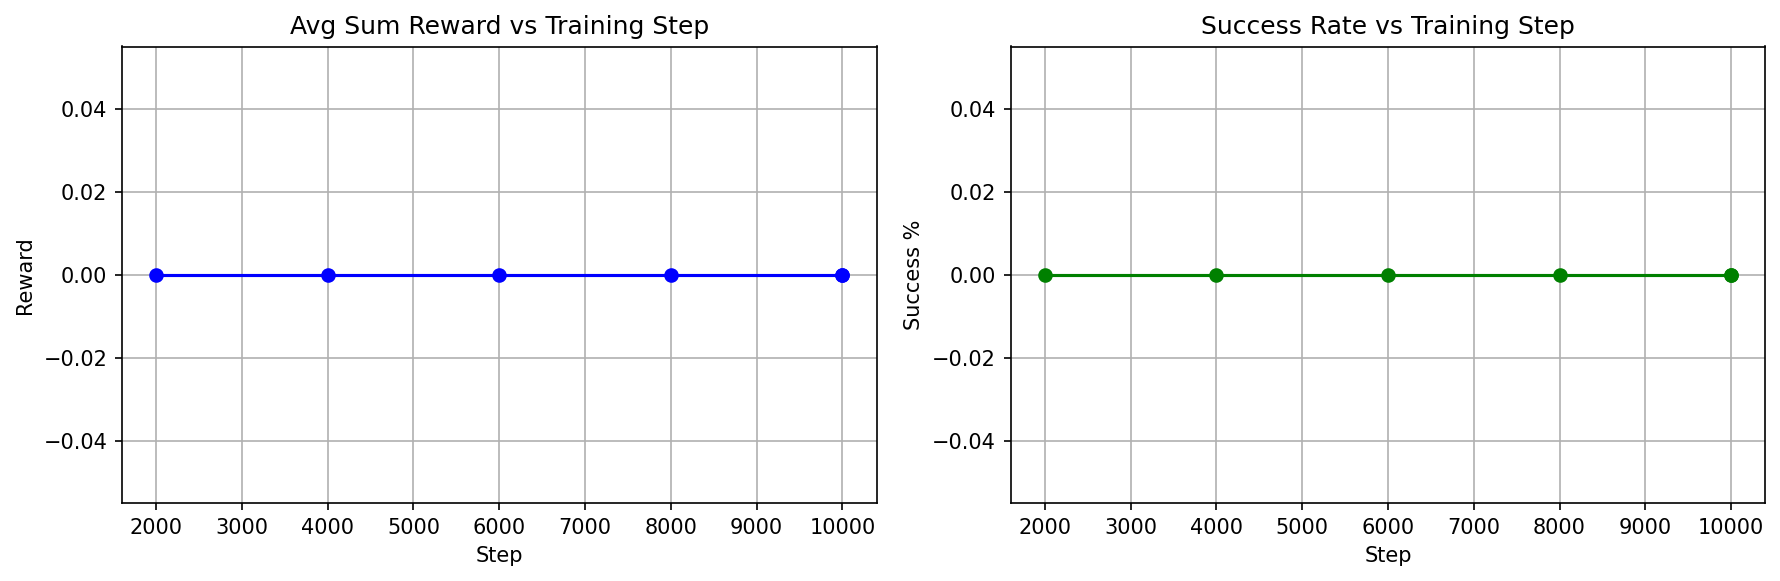


Results:
  Step 2000: reward=0.000, success=0.0%
  Step 4000: reward=0.000, success=0.0%
  Step 6000: reward=0.000, success=0.0%
  Step 8000: reward=0.000, success=0.0%
  Step 10000: reward=0.000, success=0.0%
  Step 10000: reward=0.000, success=0.0%


In [105]:
import json
import matplotlib
matplotlib.use('agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image

with open("/content/eval_all_checkpoints.json") as f:
    results = json.load(f)

steps = []
rewards = []
successes = []

for step_name, info in results.items():
    if info is None:
        continue
    # Handle "last" checkpoint
    try:
        step_num = int(step_name)
    except ValueError:
        step_num = max(steps) if steps else 500  # "last" = final step

    steps.append(step_num)
    rewards.append(info["overall"]["avg_sum_reward"])
    successes.append(info["overall"]["pc_success"])

# Sort by step
sorted_data = sorted(zip(steps, rewards, successes))
steps, rewards, successes = zip(*sorted_data)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(steps, rewards, 'b-o')
axes[0].set_title("Avg Sum Reward vs Training Step")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Reward")
axes[0].grid(True)

axes[1].plot(steps, successes, 'g-o')
axes[1].set_title("Success Rate vs Training Step")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Success %")
axes[1].grid(True)

plt.tight_layout()
plt.savefig("/content/reward_curve.png", dpi=150, bbox_inches='tight')
plt.close()
display(Image("/content/reward_curve.png"))

print("\nResults:")
for s, r, sc in zip(steps, rewards, successes):
    print(f"  Step {s}: reward={r:.3f}, success={sc:.1f}%")

In [102]:
# With LoRA
!cd lerobot && MUJOCO_GL=egl PYOPENGL_PLATFORM=egl MPLBACKEND=agg python src/lerobot/scripts/lerobot_train.py \
  --policy.path=lerobot/smolvla_base \
  --dataset.repo_id=HuggingFaceVLA/libero \
  --env.type=libero \
  --env.task=libero_object \
  --batch_size=4 \
  --steps=20000 \
  --eval_freq=0 \
  --log_freq=100 \
  --save_freq=4000 \
  --seed=1000 \
  --wandb.enable=true \
  --wandb.project=smolvla-libero \
  --output_dir=outputs/train/ablation_lora_5 \
  --job_name=ablation_lora_5 \
  --policy.device=cuda \
  --policy.push_to_hub=false \
  --peft.method_type=lora \
  --peft.r=16 \
  --rename_map='{"observation.images.image": "observation.images.camera1", "observation.images.image2": "observation.images.camera2"}' \
  2>&1 | tee /content/training_log_lora.txt

INFO 2026-03-20 00:02:25 ot_train.py:197 {'batch_size': 16,
 'checkpoint_path': None,
 'cudnn_deterministic': False,
 'dataset': {'episodes': None,
             'image_transforms': {'enable': False,
                                  'max_num_transforms': 3,
                                  'random_order': False,
                                  'tfs': {'affine': {'kwargs': {'degrees': [-5.0,
                                                                            5.0],
                                                                'translate': [0.05,
                                                                              0.05]},
                                                     'type': 'RandomAffine',
                                                     'weight': 1.0},
                                          'brightness': {'kwargs': {'brightness': [0.8,
                                                                                   1.2]},
                           

In [106]:
from huggingface_hub import login, HfApi

# Step 1 — Login (if you haven't already)
login()

# Step 2 — Create repo and upload
api = HfApi()
api.create_repo(repo_id="milpdio/ablation_lora_5", repo_type="model", exist_ok=True)

api.upload_folder(
    folder_path="/content/lerobot/outputs/train/ablation_lora_5/checkpoints/last/pretrained_model",
    repo_id="milpdio/ablation_lora_5",
    repo_type="model",
)
print("✅ Uploaded to https://huggingface.co/milpdio/ablation_lora_5")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...zer_processor.safetensors: 100%|##########| 7.67kB / 7.67kB            

  ...zer_processor.safetensors: 100%|##########| 7.67kB / 7.67kB            

  ...d_model/model.safetensors:  18%|#7        |  160MB /  907MB            

No files have been modified since last commit. Skipping to prevent empty commit.


✅ Uploaded to https://huggingface.co/milpdio/my_smolvla


In [ ]:
%%writefile /tmp/eval_checkpoints_lora.py
import os, json, glob, subprocess, re

os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"
os.environ["MPLBACKEND"] = "agg"

base_dir = "/content/lerobot/outputs/train/ablation_lora_5/checkpoints"
results = {}

checkpoints = sorted(glob.glob(os.path.join(base_dir, "*/pretrained_model")))
print(f"Found {len(checkpoints)} checkpoints\n")

rename_map = '\'{"observation.images.image": "observation.images.camera1", "observation.images.image2": "observation.images.camera2"}\''

for ckpt_path in checkpoints:
    step = ckpt_path.split("/")[-2]
    print(f"Evaluating checkpoint: step {step}")

    out_dir = f"/content/eval_checkpoints/ablation_lora_5/step_{step}"

    cmd = (
        f"cd /content/lerobot && MUJOCO_GL=egl PYOPENGL_PLATFORM=egl MPLBACKEND=agg "
        f"python -m lerobot.scripts.lerobot_eval "
        f"--policy.path={ckpt_path} "
        f"--env.type=libero "
        f"--env.task=libero_object "
        f"--env.task_ids='[0]' "
        f"--eval.batch_size=1 "
        f"--eval.n_episodes=3 "
        f"--output_dir={out_dir} "
        f"--rename_map={rename_map}"
    )

    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)

    full_output = result.stdout + result.stderr

    # Try to find eval_info.json first
    eval_files = glob.glob(os.path.join(out_dir, "**", "eval_info.json"), recursive=True)
    if eval_files:
        with open(eval_files[0]) as f:
            eval_info = json.load(f)
        results[step] = eval_info
        print(f"  ✅ {eval_info}")
        continue

    # If no json, try parsing stdout for metrics
    reward_match = re.search(r'avg_sum_reward[:\s]+([0-9.]+)', full_output)
    success_match = re.search(r'pc_success[:\s]+([0-9.]+)', full_output)

    if reward_match or success_match:
        parsed = {}
        if reward_match:
            parsed["avg_sum_reward"] = float(reward_match.group(1))
        if success_match:
            parsed["pc_success"] = float(success_match.group(1))
        results[step] = parsed
        print(f"  ✅ (from stdout) {parsed}")
        continue

    # Check all files that were created
    if os.path.exists(out_dir):
        for root, dirs, files in os.walk(out_dir):
            for f in files:
                print(f"  Found file: {os.path.join(root, f)}")

    # Print last bit of output for debugging
    clean_output = [line for line in full_output.split('\n')
                    if 'EGLError' not in line and '__del__' not in line
                    and 'eglDestroy' not in line and 'Exception ignored' not in line
                    and line.strip()]
    print(f"  ❌ No results found. Last output lines:")
    for line in clean_output[-10:]:
        print(f"    {line}")

    results[step] = None

with open("/content/eval_all_checkpoints.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"\n{'='*50}")
print(f"Results for {len([v for v in results.values() if v])} / {len(checkpoints)} checkpoints:")
for step, info in sorted(results.items(), key=lambda x: int(x[0])):
    if info:
        print(f"  Step {step}: {info}")
    else:
        print(f"  Step {step}: FAILED")

In [ ]:
!cd /content/lerobot && python /tmp/eval_checkpoints_lora.py

In [ ]:
import json
import matplotlib
matplotlib.use('agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image

with open("/content/eval_all_checkpoints.json") as f:
    results = json.load(f)

steps = []
rewards = []
successes = []

for step_name, info in results.items():
    if info is None:
        continue
    # Handle "last" checkpoint
    try:
        step_num = int(step_name)
    except ValueError:
        step_num = max(steps) if steps else 500  # "last" = final step

    steps.append(step_num)
    rewards.append(info["overall"]["avg_sum_reward"])
    successes.append(info["overall"]["pc_success"])

# Sort by step
sorted_data = sorted(zip(steps, rewards, successes))
steps, rewards, successes = zip(*sorted_data)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(steps, rewards, 'b-o')
axes[0].set_title("Avg Sum Reward vs Training Step")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Reward")
axes[0].grid(True)

axes[1].plot(steps, successes, 'g-o')
axes[1].set_title("Success Rate vs Training Step")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Success %")
axes[1].grid(True)

plt.tight_layout()
plt.savefig("/content/reward_curve.png", dpi=150, bbox_inches='tight')
plt.close()
display(Image("/content/reward_curve.png"))

print("\nResults:")
for s, r, sc in zip(steps, rewards, successes):
    print(f"  Step {s}: reward={r:.3f}, success={sc:.1f}%")

In [ ]:
# !cd lerobot && MUJOCO_GL=egl PYOPENGL_PLATFORM=egl MPLBACKEND=agg python -m lerobot.scripts.lerobot_eval \
#   --policy.path=/content/lerobot/outputs/train/my_smolvla/checkpoints/last/pretrained_model \
#   --env.type=libero \
#   --env.task=libero_object \
#   --env.task_ids='[0]' \
#   --eval.batch_size=1 \
#   --eval.n_episodes=1 \
#   --rename_map='{"observation.images.image": "observation.images.camera1", "observation.images.image2": "observation.images.camera2"}'

In [111]:
import glob

print("=== ablation_lora videos ===")
lora_videos = glob.glob("/content/eval_checkpoints_lora/**/*.mp4", recursive=True)
if not lora_videos:
    lora_videos = glob.glob("/content/lerobot/outputs/**/ablation_lora*/**/*.mp4", recursive=True)
if not lora_videos:
    lora_videos = glob.glob("/content/**/lora*/**/*.mp4", recursive=True)
for v in lora_videos:
    print(f"  {v}")

print("\n=== smolvla_long videos ===")
long_videos = glob.glob("/content/eval_checkpoints/**/*.mp4", recursive=True)
if not long_videos:
    long_videos = glob.glob("/content/lerobot/outputs/**/smolvla_long*/**/*.mp4", recursive=True)
for v in long_videos:
    print(f"  {v}")

print("\n=== ALL .mp4 files ===")
all_videos = glob.glob("/content/**/*.mp4", recursive=True)
for v in sorted(all_videos):
    print(f"  {v}")

=== ablation_lora videos ===

=== smolvla_long videos ===
  /content/eval_checkpoints/step_010000/videos/libero_object_0/eval_episode_1.mp4
  /content/eval_checkpoints/step_010000/videos/libero_object_0/eval_episode_0.mp4
  /content/eval_checkpoints/step_010000/videos/libero_object_0/eval_episode_2.mp4
  /content/eval_checkpoints/step_000100/videos/libero_object_0/eval_episode_1.mp4
  /content/eval_checkpoints/step_000100/videos/libero_object_0/eval_episode_0.mp4
  /content/eval_checkpoints/step_000100/videos/libero_object_0/eval_episode_2.mp4
  /content/eval_checkpoints/step_004000/videos/libero_object_0/eval_episode_1.mp4
  /content/eval_checkpoints/step_004000/videos/libero_object_0/eval_episode_0.mp4
  /content/eval_checkpoints/step_004000/videos/libero_object_0/eval_episode_2.mp4
  /content/eval_checkpoints/step_008000/videos/libero_object_0/eval_episode_1.mp4
  /content/eval_checkpoints/step_008000/videos/libero_object_0/eval_episode_0.mp4
  /content/eval_checkpoints/step_008000/

In [107]:
from IPython.display import Video, display

# Display the eval videos
print("Video 1:")
display(Video("/content/eval_checkpoints/step_last/videos/libero_object_0/eval_episode_2.mp4", embed=True, width=480))

print("\nVideo 2:")
display(Video("/content/eval_checkpoints/step_last/videos/libero_object_0/eval_episode_2.mp4", embed=True, width=480))

Video 1:



Video 2:
